# Store Sales Forecasting — Modeling
This notebook covers baseline forecast, Prophet, and LightGBM with lag features.

## 2. Loading Data & imports

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib

In [43]:
train = pd.read_csv("../data/train.csv")
holidays = pd.read_csv("../data/holidays_events.csv")

In [3]:
train['date'] = pd.to_datetime(train['date'])

In [4]:
train['day_of_week'] = train['date'].dt.dayofweek

In [5]:
daily_sales = train.groupby('date').agg(
    total_sales=('sales', 'sum')
)
week_sales = train.groupby('day_of_week').agg(
    total_sales_wek=('sales', 'mean')
)
split_date = '2017-05-15'
train_df = daily_sales[daily_sales.index < split_date]
test_df = daily_sales[daily_sales.index >= split_date]

In [6]:
print(train_df.shape)
print(test_df.shape)
print(train_df.index.min(), train_df.index.max())
print(test_df.index.min(), test_df.index.max())

(1591, 1)
(93, 1)
2013-01-01 00:00:00 2017-05-14 00:00:00
2017-05-15 00:00:00 2017-08-15 00:00:00


## 3. Baseline — Naive Forecast

In [7]:
naive_pred = test_df['total_sales'].shift(1).dropna()

In [8]:
mae = mean_absolute_error(test_df['total_sales'].iloc[1:], naive_pred)
print(f'Naive MAE: {mae:.2f}')

Naive MAE: 143714.48


## 4. Prophet

In [9]:
train_prophet = train_df.reset_index()

In [10]:
train_prophet.head()

,date,total_sales
0,2013-01-01,2511.618999
1,2013-01-02,496092.417944
2,2013-01-03,361461.231124
3,2013-01-04,354459.677093
4,2013-01-05,477350.121229


In [11]:
train_prophet = train_prophet.rename(columns={'date': 'ds', 'total_sales': 'y'})
test_prophet = test_df.reset_index().rename(columns={'date': 'ds', 'total_sales': 'y'})

In [12]:
model_prophet = Prophet()
model_prophet.fit(train_prophet)
future_prophet = model_prophet.make_future_dataframe(periods=93)
forecast_prophet = model_prophet.predict(future_prophet)

08:25:13 - cmdstanpy - INFO - Chain [1] start processing
08:25:13 - cmdstanpy - INFO - Chain [1] done processing


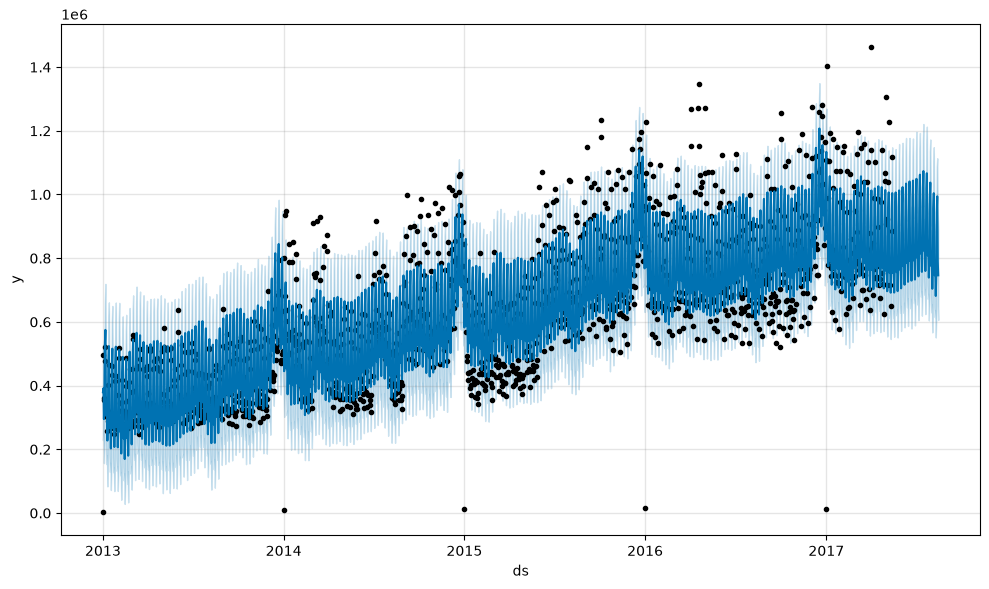

In [13]:
model_prophet.plot(forecast_prophet)
plt.show()

In [14]:
mae_prophet = mean_absolute_error(forecast_prophet.tail(93)['yhat'], test_prophet['y'])
print(f'Prophet MAE: {mae_prophet:.2f}')

Prophet MAE: 70890.09


## 5. LightGBM with Lag Features

In [15]:
daily_sales_lgbm = daily_sales.copy()
daily_sales_lgbm['lag_1'] = daily_sales_lgbm['total_sales'].shift(1)
daily_sales_lgbm['lag_7'] = daily_sales_lgbm['total_sales'].shift(7)
daily_sales_lgbm['lag_30'] = daily_sales_lgbm['total_sales'].shift(30)
daily_sales_lgbm = daily_sales_lgbm.dropna()

In [16]:
daily_sales_lgbm.head()

,total_sales,lag_1,lag_7,lag_30
date,,,,
2013-01-31,271254.217996,281061.127052,247245.690995,2511.618999
2013-02-01,369402.055266,271254.217996,290022.771930,496092.417944
2013-02-02,518887.462705,369402.055266,413799.767975,361461.231124
2013-02-03,486336.820180,518887.462705,430411.991233,354459.677093
2013-02-04,344308.715017,486336.820180,285460.169953,477350.121229


In [17]:
train_lgbm = daily_sales_lgbm[daily_sales_lgbm.index < split_date]
test_lgbm = daily_sales_lgbm[daily_sales_lgbm.index >= split_date]

In [18]:
features = ['lag_1', 'lag_7', 'lag_30']
X_train = train_lgbm[features]
y_train = train_lgbm['total_sales']
X_test = test_lgbm[features]
y_test = test_lgbm['total_sales']

In [19]:
model_lgbm = lgb.LGBMRegressor()
model_lgbm.fit(X_train, y_train)
y_pred_lgbm = model_lgbm.predict(X_test)

mae_lgbm = mean_absolute_error(y_pred_lgbm, y_test)
print(f'LightGBM MAE: {mae_lgbm:.2f}')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000121 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 1561, number of used features: 3
[LightGBM] [Info] Start training from score 630444.903768
LightGBM MAE: 85116.39


In [20]:
daily_sales_lgbm['lag_14'] = daily_sales_lgbm['total_sales'].shift(14)
daily_sales_lgbm['day_of_week'] = daily_sales_lgbm.index.dayofweek
daily_sales_lgbm['month'] = daily_sales_lgbm.index.month
daily_sales_lgbm = daily_sales_lgbm.dropna()

In [21]:
train_lgbm = daily_sales_lgbm[daily_sales_lgbm.index < split_date]
test_lgbm = daily_sales_lgbm[daily_sales_lgbm.index >= split_date]

In [22]:
features = ['lag_1', 'lag_7', 'lag_30', 'lag_14', 'day_of_week', 'month']
X_train = train_lgbm[features]
y_train = train_lgbm['total_sales']
X_test = test_lgbm[features]
y_test = test_lgbm['total_sales']

In [23]:
model_lgbm_plus = lgb.LGBMRegressor()
model_lgbm_plus.fit(X_train, y_train)
y_pred_lgbm_plus = model_lgbm_plus.predict(X_test)

mae_lgbm_plus = mean_absolute_error(y_pred_lgbm_plus, y_test)
print(f'LightGBM+ MAE: {mae_lgbm_plus:.2f}')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000093 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1040
[LightGBM] [Info] Number of data points in the train set: 1547, number of used features: 6
[LightGBM] [Info] Start training from score 632985.855345
LightGBM+ MAE: 54452.97


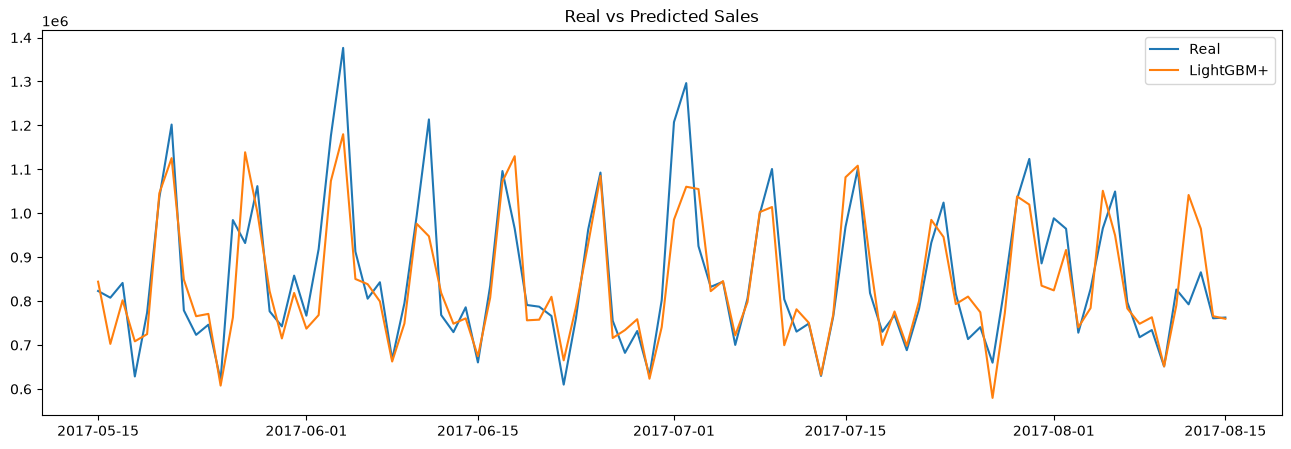

In [40]:
plt.figure(figsize=(16, 5))
plt.plot(y_test.index, y_test, label='Real')
plt.plot(y_test.index, y_pred_lgbm_plus, label='LightGBM+')
plt.legend()
plt.title('Real vs Predicted Sales')
plt.show()

In [24]:
results = pd.DataFrame({
    'Model': ['Naive', 'Prophet', 'LightGBM', 'LightGBM+'],
    'MAE': [143714, mae_prophet, mae_lgbm, mae_lgbm_plus]
})

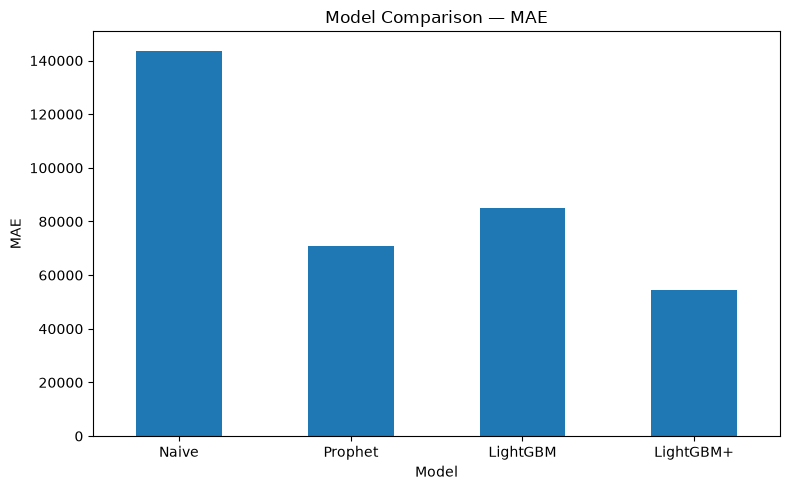

In [25]:
results.plot(kind='bar', x='Model', y='MAE', figsize=(8, 5), legend=False)
plt.title('Model Comparison — MAE')
plt.ylabel('MAE')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. LightGBM with holidays

In [26]:
holidays.head()

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


In [27]:
holidays['date'] = pd.to_datetime(holidays['date']) 
daily_sales_lgbm_reset = daily_sales_lgbm.reset_index()
ds_lgbm_holidays = pd.merge(daily_sales_lgbm_reset, holidays, how='left', on='date')

In [28]:
ds_lgbm_holidays.head()

,date,total_sales,lag_1,lag_7,lag_30,lag_14,day_of_week,month,type,locale,locale_name,description,transferred
0,2013-02-14,308164.016957,319597.929962,290807.530973,299129.549954,271254.217996,3,2,NaN,NaN,NaN,NaN,NaN
1,2013-02-15,320168.883912,308164.016957,347441.789912,318347.913946,369402.055266,4,2,NaN,NaN,NaN,NaN,NaN
2,2013-02-16,485660.494008,320168.883912,416176.279075,267498.515975,518887.462705,5,2,NaN,NaN,NaN,NaN,NaN
3,2013-02-17,399588.910014,485660.494008,300951.328993,296130.850028,486336.820180,6,2,NaN,NaN,NaN,NaN,NaN
4,2013-02-18,350745.573191,399588.910014,278627.588926,432459.852021,344308.715017,0,2,NaN,NaN,NaN,NaN,NaN


In [29]:
ds_lgbm_holidays['is_holiday'] = ds_lgbm_holidays['type'].notna().astype(int)

In [30]:
ds_lgbm_holidays.head()

,date,total_sales,lag_1,lag_7,lag_30,lag_14,day_of_week,month,type,locale,locale_name,description,transferred,is_holiday
0,2013-02-14,308164.016957,319597.929962,290807.530973,299129.549954,271254.217996,3,2,NaN,NaN,NaN,NaN,NaN,0
1,2013-02-15,320168.883912,308164.016957,347441.789912,318347.913946,369402.055266,4,2,NaN,NaN,NaN,NaN,NaN,0
2,2013-02-16,485660.494008,320168.883912,416176.279075,267498.515975,518887.462705,5,2,NaN,NaN,NaN,NaN,NaN,0
3,2013-02-17,399588.910014,485660.494008,300951.328993,296130.850028,486336.820180,6,2,NaN,NaN,NaN,NaN,NaN,0
4,2013-02-18,350745.573191,399588.910014,278627.588926,432459.852021,344308.715017,0,2,NaN,NaN,NaN,NaN,NaN,0


In [31]:
ds_lgbm_holidays = ds_lgbm_holidays.set_index('date')
train_lgbm = ds_lgbm_holidays[ds_lgbm_holidays.index < split_date]
test_lgbm = ds_lgbm_holidays[ds_lgbm_holidays.index >= split_date]
features = ['lag_1', 'lag_7', 'lag_30', 'lag_14', 'day_of_week', 'month', 'is_holiday']
X_train = train_lgbm[features]
y_train = train_lgbm['total_sales']
X_test = test_lgbm[features]
y_test = test_lgbm['total_sales']

In [32]:
model_lgbm_holidays = lgb.LGBMRegressor()
model_lgbm_holidays.fit(X_train, y_train)
y_pred_lgbm_holidays = model_lgbm_holidays.predict(X_test)

mae_lgbm_holidays = mean_absolute_error(y_pred_lgbm_holidays, y_test)
print(f'LightGBM+ Holidays MAE: {mae_lgbm_holidays:.2f}')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000085 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1042
[LightGBM] [Info] Number of data points in the train set: 1574, number of used features: 7
[LightGBM] [Info] Start training from score 634719.533057
LightGBM+ Holidays MAE: 58549.32


## 7. LightGBM with Holidays
Adding holiday features did not improve the model — MAE increased from 54,452 to 58,549.
This is likely because holidays in Ecuador vary by region and do not uniformly affect all stores.

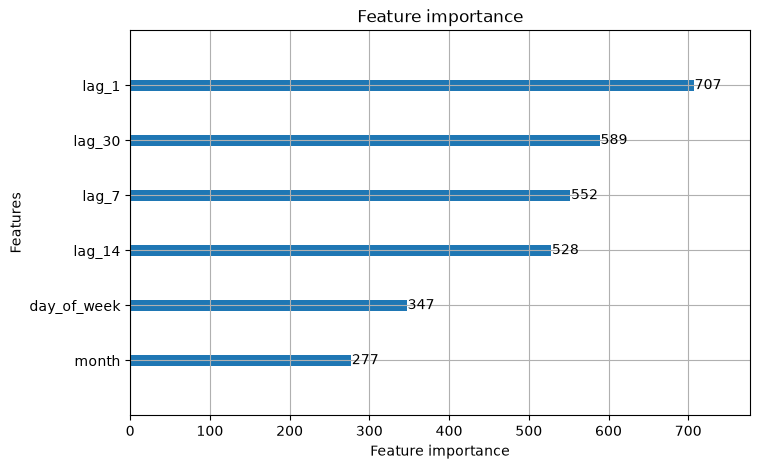

In [33]:
lgb.plot_importance(model_lgbm_plus, figsize=(8, 5))
plt.show()

## Conclusion
We compared three forecasting approaches on aggregated daily store sales.
LightGBM with lag features (lag_1, lag_7, lag_14, lag_30), day_of_week, and month
outperformed both Naive baseline and Prophet, achieving MAE of ~58,500 units.
Key insight: recent sales (lag_1) are the strongest predictor of future sales.

In [45]:
joblib.dump(model_lgbm_plus, '../models/lgbm_store_sales.pkl')

['../models/lgbm_store_sales.pkl']